<a href="https://colab.research.google.com/github/kaviyasri2405/machine-learning/blob/main/ex_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import subprocess

# Install graphviz for tree visualization
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'graphviz'])

0

Original Dataset:


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes



Encoded Dataset:


,Outlook_encoded,Temperature_encoded,Humidity_encoded,Wind_encoded,Play_encoded
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1



Decision Tree Model trained successfully.

New sample features (encoded for prediction):


,Outlook_encoded,Temperature_encoded,Humidity_encoded,Wind_encoded
0,2,0,0,0


Predicted class for the new sample: No

Decision Tree Visualization:


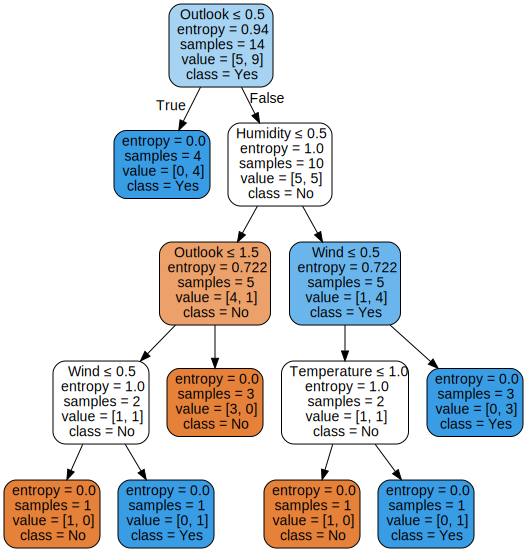

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import graphviz
import io

# 1. Create a sample dataset suitable for decision tree (ID3-like) demonstration
# This dataset is inspired by the classic 'Play Tennis' example.
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)

# Display the initial dataset
print("Original Dataset:")
display(df.head())

# 2. Encode categorical features and the target variable into numerical format
# ID3 works with categorical features, so we convert them to numerical representation.
le_outlook = LabelEncoder()
le_temperature = LabelEncoder()
le_humidity = LabelEncoder()
le_wind = LabelEncoder()
le_play = LabelEncoder() # Encoder for the target variable 'Play'

df['Outlook_encoded'] = le_outlook.fit_transform(df['Outlook'])
df['Temperature_encoded'] = le_temperature.fit_transform(df['Temperature'])
df['Humidity_encoded'] = le_humidity.fit_transform(df['Humidity'])
df['Wind_encoded'] = le_wind.fit_transform(df['Wind'])
df['Play_encoded'] = le_play.fit_transform(df['Play'])

# Display the encoded dataset
print("\nEncoded Dataset:")
display(df[['Outlook_encoded', 'Temperature_encoded', 'Humidity_encoded', 'Wind_encoded', 'Play_encoded']].head())

# 3. Define features (X) and target (y)
X = df[['Outlook_encoded', 'Temperature_encoded', 'Humidity_encoded', 'Wind_encoded']]
y = df['Play_encoded']

# 4. Train a Decision Tree Classifier using 'entropy' criterion
# The 'entropy' criterion in sklearn's DecisionTreeClassifier is based on information gain,
# which is the core splitting mechanism of the ID3 algorithm.
# random_state is set for reproducibility.
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)

print("\nDecision Tree Model trained successfully.")

# 5. Classify a new sample using the trained model
# Example new sample: Sunny, Cool, High, Strong
new_sample_data = {
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
}
new_sample_df = pd.DataFrame(new_sample_data)

# Encode the new sample using the *same* LabelEncoders used for training data
new_sample_df['Outlook_encoded'] = le_outlook.transform(new_sample_df['Outlook'])
new_sample_df['Temperature_encoded'] = le_temperature.transform(new_sample_df['Temperature'])
new_sample_df['Humidity_encoded'] = le_humidity.transform(new_sample_df['Humidity'])
new_sample_df['Wind_encoded'] = le_wind.transform(new_sample_df['Wind'])

new_sample_X = new_sample_df[['Outlook_encoded', 'Temperature_encoded', 'Humidity_encoded', 'Wind_encoded']]

prediction_encoded = model.predict(new_sample_X)
# Inverse transform the prediction to get the original label (e.g., 'Yes' or 'No')
prediction_label = le_play.inverse_transform(prediction_encoded)

print("\nNew sample features (encoded for prediction):")
display(new_sample_X)
print(f"Predicted class for the new sample: {prediction_label[0]}")

# 6. Visualize the Decision Tree
# This step requires graphviz to be installed.
feature_names = ['Outlook', 'Temperature', 'Humidity', 'Wind']
class_names = le_play.classes_.tolist() # Get original class names (e.g., ['No', 'Yes'])

dot_data = io.StringIO()
export_graphviz(model, out_file=dot_data,
                feature_names=feature_names,
                class_names=class_names,
                filled=True, rounded=True,
                special_characters=True)
graph = graphviz.Source(dot_data.getvalue())

print("\nDecision Tree Visualization:")
display(graph)